In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Set plotting style for better visuals
plt.style.use('seaborn-v0_8-darkgrid')

# Let's start with the State-level data. 
# Make sure 'State_time_series.csv' is in the same directory as your notebook.
# If it's inside a folder, adjust the path (e.g., 'data/State_time_series.csv')
file_path = 'data/State_time_series.csv'

try:
    df_state = pd.read_csv(file_path)
    
    # Convert 'Date' column to proper datetime objects
    df_state['Date'] = pd.to_datetime(df_state['Date']) 
    
    print(f"Dataset Shape: {df_state.shape}\n")
    print("--- Data Types and Missing Values ---")
    
    # We use info() to see which columns have the most non-null values
    df_state.info()
    
    print("\n--- First 5 rows ---")
    display(df_state.head()) # 'display' renders a nice HTML table in Jupyter

except FileNotFoundError:
    print(f"Error: Could not find '{file_path}'. Please check that you extracted the Kaggle files in the correct folder.")

Dataset Shape: (13212, 82)

--- Data Types and Missing Values ---
<class 'pandas.DataFrame'>
RangeIndex: 13212 entries, 0 to 13211
Data columns (total 82 columns):
 #   Column                                                         Non-Null Count  Dtype         
---  ------                                                         --------------  -----         
 0   Date                                                           13212 non-null  datetime64[us]
 1   RegionName                                                     13212 non-null  str           
 2   DaysOnZillow_AllHomes                                          4845 non-null   float64       
 3   InventorySeasonallyAdjusted_AllHomes                           4896 non-null   float64       
 4   InventoryRaw_AllHomes                                          4896 non-null   float64       
 5   MedianListingPricePerSqft_1Bedroom                             3586 non-null   float64       
 6   MedianListingPricePerSqft_2Bedroom     

,Date,RegionName,DaysOnZillow_AllHomes,InventorySeasonallyAdjusted_AllHomes,InventoryRaw_AllHomes,MedianListingPricePerSqft_1Bedroom,MedianListingPricePerSqft_2Bedroom,MedianListingPricePerSqft_3Bedroom,MedianListingPricePerSqft_4Bedroom,MedianListingPricePerSqft_5BedroomOrMore,...,ZHVI_BottomTier,ZHVI_CondoCoop,ZHVI_MiddleTier,ZHVI_SingleFamilyResidence,ZHVI_TopTier,ZRI_AllHomes,ZRI_AllHomesPlusMultifamily,ZriPerSqft_AllHomes,Zri_MultiFamilyResidenceRental,Zri_SingleFamilyResidenceRental
0,1996-04-30,Alabama,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,45600.0,99500.0,79500.0,79000.0,140200.0,NaN,NaN,NaN,NaN,NaN
1,1996-04-30,Arizona,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,67100.0,78900.0,103600.0,107500.0,168700.0,NaN,NaN,NaN,NaN,NaN
2,1996-04-30,Arkansas,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,38400.0,70300.0,64400.0,64500.0,115200.0,NaN,NaN,NaN,NaN,NaN
3,1996-04-30,California,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,95100.0,136100.0,157900.0,162000.0,270600.0,NaN,NaN,NaN,NaN,NaN
4,1996-04-30,Colorado,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,82700.0,99400.0,128100.0,133600.0,209300.0,NaN,NaN,NaN,NaN,NaN


--- Time Series Info for California ---
Start Date: 2010-01-31
End Date:   2017-12-31
Total months (data points): 96



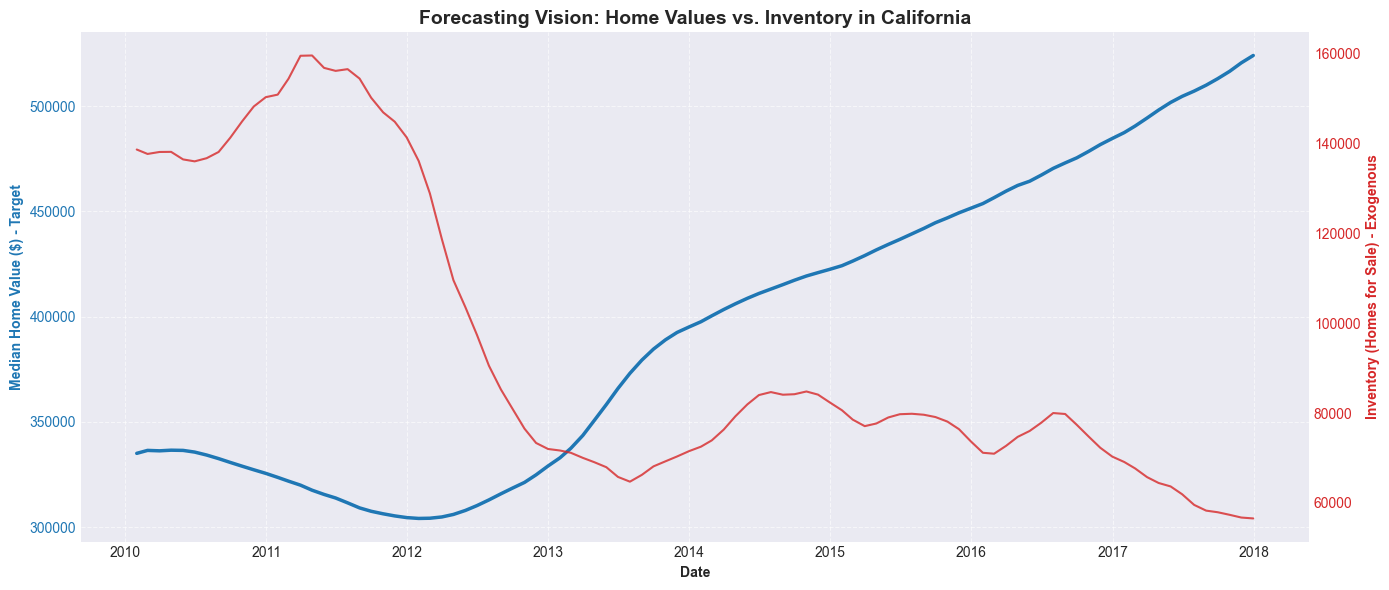

In [2]:
# Cell 2: Selecting a specific time series, target, and exogenous variable

# 1. Filter for a specific state (Forecasting multiple states at once is a panel-data problem, 
# for a standard time series forecasting task, we focus on one specific series first).
state_to_analyze = 'California' 
df_state_filtered = df_state[df_state['RegionName'] == state_to_analyze].copy()

# 2. Set the Date as the index for time series operations and sort it
df_state_filtered.set_index('Date', inplace=True)
df_state_filtered.sort_index(inplace=True)

# 3. Define our Forecasting Target and Exogenous Variable
target_col = 'ZHVI_MiddleTier' # Variable to predict: Median Home Value
exog_col = 'InventorySeasonallyAdjusted_AllHomes' # Exogenous variable: Supply of homes

# 4. Handle Missing Values: Drop rows where our exogenous variable hasn't been recorded yet (pre-2010)
df_model = df_state_filtered[[target_col, exog_col]].dropna()

print(f"--- Time Series Info for {state_to_analyze} ---")
print(f"Start Date: {df_model.index.min().date()}")
print(f"End Date:   {df_model.index.max().date()}")
print(f"Total months (data points): {len(df_model)}\n")

# 5. Visualizing the relationship (Target vs Exogenous)
fig, ax1 = plt.subplots(figsize=(14, 6))

# Plot Target Variable (Prices)
color1 = '#1f77b4' # Matplotlib blue
ax1.set_xlabel('Date', fontweight='bold')
ax1.set_ylabel('Median Home Value ($) - Target', color=color1, fontweight='bold')
ax1.plot(df_model.index, df_model[target_col], color=color1, linewidth=2.5, label='Price (ZHVI)')
ax1.tick_params(axis='y', labelcolor=color1)
ax1.grid(True, linestyle='--', alpha=0.6)

# Create a second y-axis to plot the Exogenous Variable (Inventory)
ax2 = ax1.twinx()  
color2 = '#d62728' # Matplotlib red
ax2.set_ylabel('Inventory (Homes for Sale) - Exogenous', color=color2, fontweight='bold')  
ax2.plot(df_model.index, df_model[exog_col], color=color2, linestyle='-', linewidth=1.5, alpha=0.8, label='Inventory')
ax2.tick_params(axis='y', labelcolor=color2)
ax2.grid(False) # Turn off grid for the second axis to avoid clutter

plt.title(f'Forecasting Vision: Home Values vs. Inventory in {state_to_analyze}', fontsize=14, fontweight='bold')
fig.tight_layout()  
plt.show()

In [3]:
# Cell 3: Stationarity and Random Walk Analysis (Augmented Dickey-Fuller Test)

from statsmodels.tsa.stattools import adfuller

def print_adf_test(series, title):
    print(f"--- Augmented Dickey-Fuller Test: {title} ---")
    result = adfuller(series, autolag='AIC')
    print(f'ADF Statistic: {result[0]:.4f}')
    print(f'p-value: {result[1]:.4f}')
    
    print('Critical Values:')
    for key, value in result[4].items():
        print(f'   {key}: {value:.4f}')
        
    # Interpretation
    if result[1] <= 0.05:
        print("Conclusion: Reject the null hypothesis. Data is STATIONARY (Not a Random Walk).")
    else:
        print("Conclusion: Fail to reject the null hypothesis. Data is NON-STATIONARY.")
    print("\n")

# 1. Test the original Target Series (Prices)
# It will likely be non-stationary due to the strong upward trend
print_adf_test(df_model[target_col], "Original ZHVI (Prices)")

# 2. Test the First-Differenced Target Series (Month-over-Month change in Price)
# This removes the trend and should ideally make the series stationary
# df_model[target_col].diff() calculates (Price_Month2 - Price_Month1)
differenced_series = df_model[target_col].diff().dropna()
print_adf_test(differenced_series, "First-Differenced ZHVI (Month-to-Month Change)")

--- Augmented Dickey-Fuller Test: Original ZHVI (Prices) ---
ADF Statistic: -0.0831
p-value: 0.9511
Critical Values:
   1%: -3.5043
   5%: -2.8939
   10%: -2.5840
Conclusion: Fail to reject the null hypothesis. Data is NON-STATIONARY.


--- Augmented Dickey-Fuller Test: First-Differenced ZHVI (Month-to-Month Change) ---
ADF Statistic: -2.1508
p-value: 0.2246
Critical Values:
   1%: -3.5043
   5%: -2.8939
   10%: -2.5840
Conclusion: Fail to reject the null hypothesis. Data is NON-STATIONARY.




In [4]:
# 3. Test the Second-Differenced Target Series (Acceleration of Price)
# This removes the momentum/acceleration of the trend to achieve strict stationarity
second_differenced_series = df_model[target_col].diff().diff().dropna()
print_adf_test(second_differenced_series, "Second-Differenced ZHVI (Strictly Stationary)")

--- Augmented Dickey-Fuller Test: Second-Differenced ZHVI (Strictly Stationary) ---
ADF Statistic: -3.9867
p-value: 0.0015
Critical Values:
   1%: -3.5043
   5%: -2.8939
   10%: -2.5840
Conclusion: Reject the null hypothesis. Data is STATIONARY (Not a Random Walk).




In [5]:
# Cell 4: Exporting the cleaned and prepared dataset for future assignments

# Define the name of your new, clean CSV file
output_filename = f'data/{state_to_analyze}_Zillow_Prepared_Data.csv'

# Save the dataframe to CSV. 
# We keep the index because it contains our crucial 'Date' information.
df_model.to_csv(output_filename)

print(f"Success! Cleaned dataset successfully saved as: '{output_filename}'")
print(f"Total rows saved: {len(df_model)}")

Success! Cleaned dataset successfully saved as: 'data/California_Zillow_Prepared_Data.csv'
Total rows saved: 96


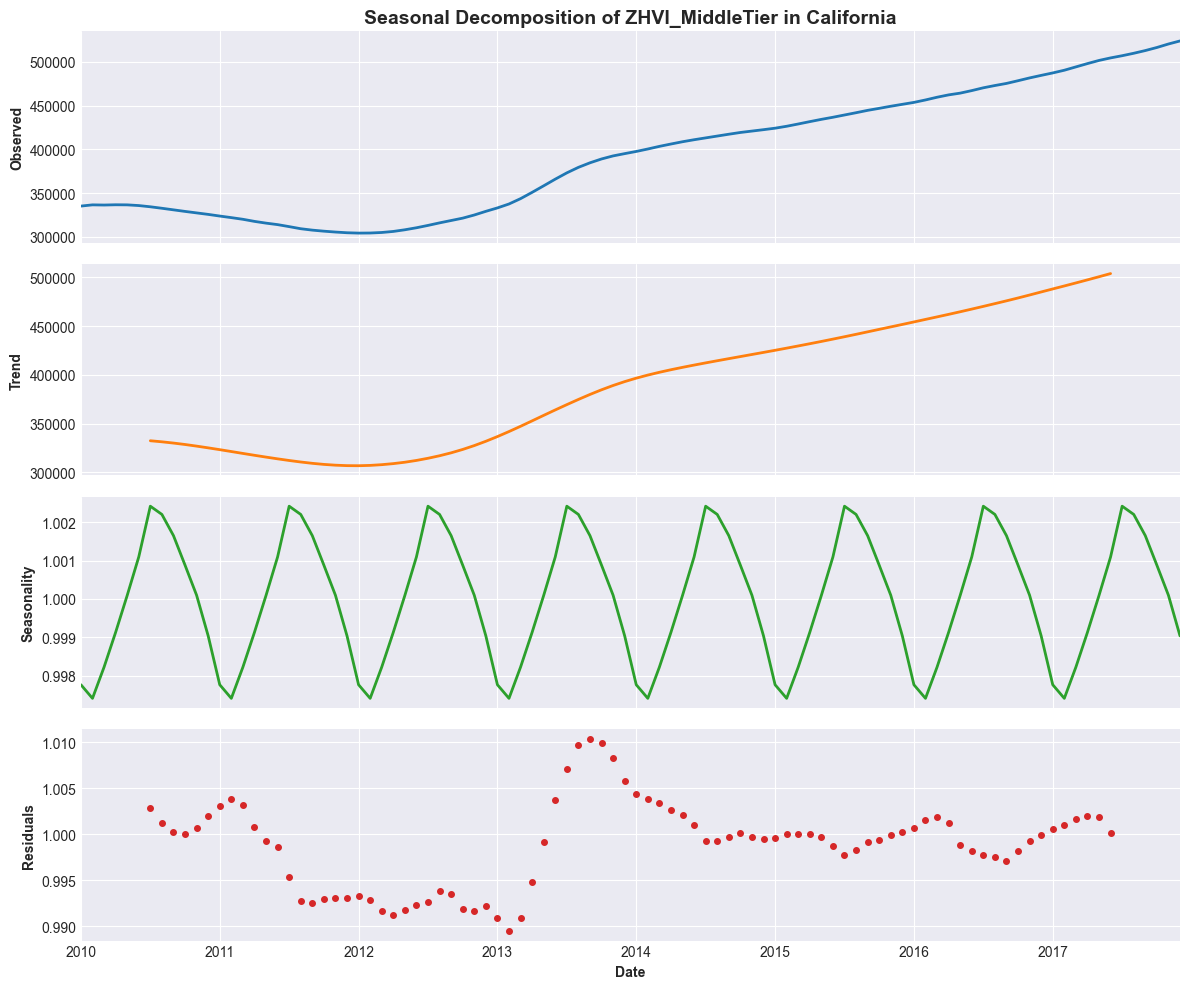

In [6]:
# Cell 5: Seasonal Decomposition Analysis

from statsmodels.tsa.seasonal import seasonal_decompose
import matplotlib.pyplot as plt

# 1. Perform seasonal decomposition on the original target series (Prices)
# We use period=12 because our data is monthly and real estate has an annual cycle (12 months)
decomposition = seasonal_decompose(df_model[target_col], model='multiplicative', period=12)

# 2. Plot the decomposition
fig, axes = plt.subplots(4, 1, figsize=(12, 10), sharex=True)

# Original Time Series
decomposition.observed.plot(ax=axes[0], color='#1f77b4', linewidth=2)
axes[0].set_ylabel('Observed', fontweight='bold')
axes[0].set_title(f'Seasonal Decomposition of {target_col} in {state_to_analyze}', fontweight='bold', fontsize=14)

# Trend Component
decomposition.trend.plot(ax=axes[1], color='#ff7f0e', linewidth=2)
axes[1].set_ylabel('Trend', fontweight='bold')

# Seasonal Component (This is what the rubric asks for!)
decomposition.seasonal.plot(ax=axes[2], color='#2ca02c', linewidth=2)
axes[2].set_ylabel('Seasonality', fontweight='bold')

# Residual Component (Noise)
decomposition.resid.plot(ax=axes[3], color='#d62728', marker='o', linestyle='none', markersize=4)
axes[3].set_ylabel('Residuals', fontweight='bold')
axes[3].set_xlabel('Date', fontweight='bold')

plt.tight_layout()
plt.show()